# Scaling Laws

A common question in neural network training is, how should I select my hyperparameters? While a proper hyperparameter sweep will always provide the best answer, sweeps can become impractical especially at larger network sizes. In this case, the field has converged to two main options: 1), copy what a previous project used (which is always a good starting point), or 2) derive *scaling laws* which can predict what the best hyperparameters will be.

In this homework question, we will derive a simple scaling law for the optimal learning rate under varying batch sizes.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch


Listed below are some util functions for plotting which you will find helpful later. Feel free to refer to them later on.

In [52]:
def preprocess_mse_array(mse_list, nan_fill=None, clip_max=None):
    """Convert list to np.array and optionally replace NaNs and clip values."""
    arr = np.array(mse_list, dtype=float)
    if nan_fill is not None:
        arr = np.where(np.isnan(arr), nan_fill, arr)
    if clip_max is not None:
        arr = np.minimum(arr, clip_max)
    return arr

def compute_best_lrs(final_mse_dict, lrs, batch_sizes, eps=0.0):
    """
    Compute the 'best' learning rate for each batch size.

    eps > 0: average all lrs whose loss is within eps of the best loss.
    eps = 0: just pick argmin.
    """
    lrs = np.array(lrs)
    best_lrs = []
    for bs in batch_sizes:
        mse = np.array(final_mse_dict[bs], dtype=float)
        best_loss = np.nanmin(mse)
        if eps > 0:
            good_mask = ~np.isnan(mse) & (mse - best_loss <= eps)
            good_lrs = lrs[good_mask]
            if good_lrs.size > 0:
                best_lr = float(good_lrs.mean())
            else:
                best_lr = float(lrs[np.nanargmin(mse)])
        else:
            best_lr = float(lrs[np.nanargmin(mse)])
        best_lrs.append(best_lr)
    return np.array(best_lrs)

def plot_lr_vs_mse(
    lrs,
    final_mse_dict,
    batch_sizes,
    title="Final Test MSE vs Learning Rate",
    nan_fill=None,
    clip_max=None,
    best_eps=0.0,
):
    """
    Plot MSE vs learning rate curves for multiple batch sizes and optionally
    mark the 'best' learning rate for each curve.
    """
    fig, ax = plt.subplots(figsize=(10, 6))
    lrs_arr = np.array(lrs)

    for bs in batch_sizes:
        raw_mse = np.array(final_mse_dict[bs], dtype=float)
        plot_mse = preprocess_mse_array(raw_mse, nan_fill=nan_fill, clip_max=clip_max)
        ax.plot(lrs_arr, plot_mse, label=f'batch_size={bs}', marker='o')

        # mark best lr
        best_loss = np.nanmin(raw_mse)
        if best_eps > 0:
            good_mask = ~np.isnan(raw_mse) & (raw_mse - best_loss <= best_eps)
            good_lrs = lrs_arr[good_mask]
            if good_lrs.size > 0:
                best_lr = float(good_lrs.mean())
            else:
                best_lr = float(lrs_arr[np.nanargmin(raw_mse)])
        else:
            best_lr = float(lrs_arr[np.nanargmin(raw_mse)])

        best_loss_for_plot = preprocess_mse_array([best_loss], nan_fill=nan_fill, clip_max=clip_max)[0]
        ax.plot(best_lr, best_loss_for_plot, marker='x', color = 'red', markersize=10)

    ax.set_xlabel('Learning Rate')
    ax.set_ylabel('Mean Squared Error')
    ax.set_title(title)
    ax.set_xscale('log')
    ax.grid(True)
    ax.legend()
    return fig, ax

def plot_best_lr_vs_batch(
    batch_sizes,
    final_mse_dict,
    lrs,
    title="Best Learning Rate vs Batch Size",
    best_eps=0.0,
):
    """
    Plot the best learning rate as a function of batch size.
    """
    best_lrs = compute_best_lrs(final_mse_dict, lrs, batch_sizes, eps=best_eps)

    fig, ax = plt.subplots(figsize=(10, 6))
    ax.plot(batch_sizes, best_lrs, marker='o')
    ax.set_xlabel('Batch Size')
    ax.set_ylabel('Best Learning Rate')
    ax.set_title(title)
    ax.set_xscale('linear')
    ax.set_yscale('linear')
    ax.grid(True)
    return fig, ax


First, let's consider the case of a simple least-squares gradient descent problem. We will define our dataset using a randomly-sampled ground truth linear mapping, and our training samples will be augmented by some amount of noise. For this homework, we will focus on the question of **how should learning rate scale with batch size?**

In [66]:
def generate_linear_regression_data(
    N=10_000,
    N_test=1_000,
    D=16,
    sigma=5.0,
    seed=0
):
    """
    Generate a synthetic linear regression dataset with Gaussian inputs and noise.

    Parameters
    ----------
    N : int
        Number of training samples.

    N_test : int
        Number of test samples.

    D : int
        Input and output dimensionality. The target is generated using a DxD true weight.

    sigma : float
        Standard deviation of Gaussian noise added to the outputs.

    seed : int
        Random seed for reproducibility.

    Returns
    -------
    X_train : ndarray, shape (N, D)
    y_train : ndarray, shape (N, D)
    X_test : ndarray, shape (N_test, D)
    y_test : ndarray, shape (N_test, D)
    w_true : ndarray, shape (D, D)
        Ground-truth weight matrix used to generate outputs.
    """
    np.random.seed(seed)

    # Inputs
    X_train = np.random.randn(N, D)
    X_test = np.random.randn(N_test, D)

    # Ground truth linear map
    w_true = np.random.randn(D, D)

    # Outputs with additive Gaussian noise
    y_train = X_train @ w_true + sigma * np.random.randn(N, D)
    y_test = X_test @ w_true + sigma * np.random.randn(N_test, D)

    return X_train, y_train, X_test, y_test, w_true

N = 10_000
N_test = 1_000
D = 16
sigma = 5.0
seed = 0
X_train, y_train, X_test, y_test, w_true = generate_linear_regression_data(
    N=N,
    N_test=N_test,
    D=D,
    sigma=sigma,
    seed=seed,
)

def analytical_solution(X, y, n):
    pseudo_inv_X = np.linalg.pinv(X[:n, :], rcond=0) # pseudo-inverse of X
    w_analytical = pseudo_inv_X @ y[:n, :] # analytical solution
    return w_analytical

def compute_mse(X, y, w):
    y_pred = X @ w # predicted outputs
    mse = np.mean((y - y_pred)**2) # mean squared error
    return mse

def compute_losses(X_train, y_train, X_test, y_test, N):
    train_losses = []
    test_losses = []
    ns = list(range(1, N+1))
    for n in ns:
        w_analytical = analytical_solution(X_train, y_train, n)
        train_mse = compute_mse(X_train, y_train, w_analytical)
        test_mse = compute_mse(X_test, y_test, w_analytical)
        train_losses.append(train_mse)
        test_losses.append(test_mse)
    return ns, train_losses, test_losses

In [61]:
def run_sgd(iters, batch_size, lr):
    np.random.seed(0)
    w_init = np.random.randn(D, D)

    test_sgd_mse = []
    train_sgd_mse = []

    w = w_init
    for i in range(iters):
        idx = np.random.randint(0, N, batch_size)
        x = X_train[idx]
        y = y_train[idx]
        grad = (2/batch_size) * (x.T @ x @ w - x.T @ y)  # shape (D, 1)

        w = w - lr * grad
        train_mse = compute_mse(x, y, w)
        test_mse = compute_mse(X_test, y_test, w)
        test_sgd_mse.append(test_mse)
        train_sgd_mse.append(train_mse)

    return train_sgd_mse, test_sgd_mse

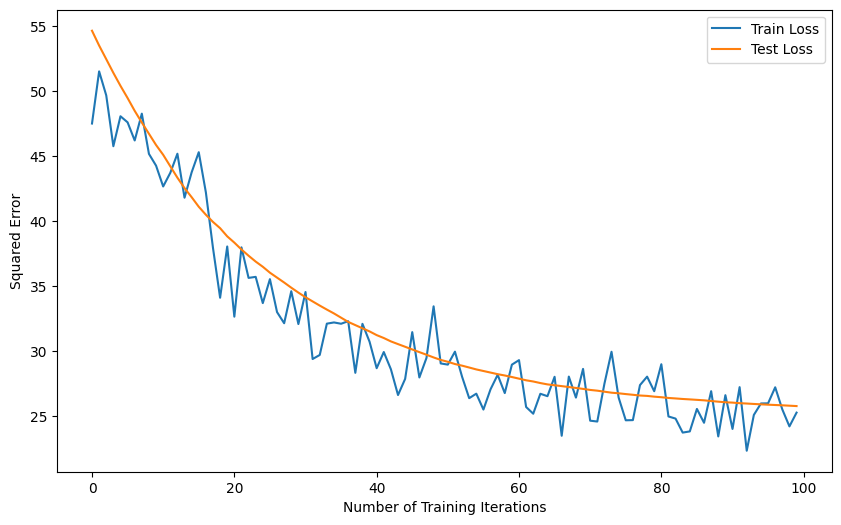

In [62]:
train_sgd_mse, test_sgd_mse = run_sgd(iters=100, batch_size=32, lr=0.01)

plt.figure(figsize=(10, 6))
plt.plot(train_sgd_mse, label='Train Loss')
plt.plot(test_sgd_mse, label='Test Loss')
plt.xlabel('Number of Training Iterations')
plt.ylabel('Squared Error')
plt.legend()

We can plot the above curves on log-linear scale while subtracting off the irreducible error of $\sigma^2$ to see the linear decay of the squared error. This allows for a better view of the convergence rate.

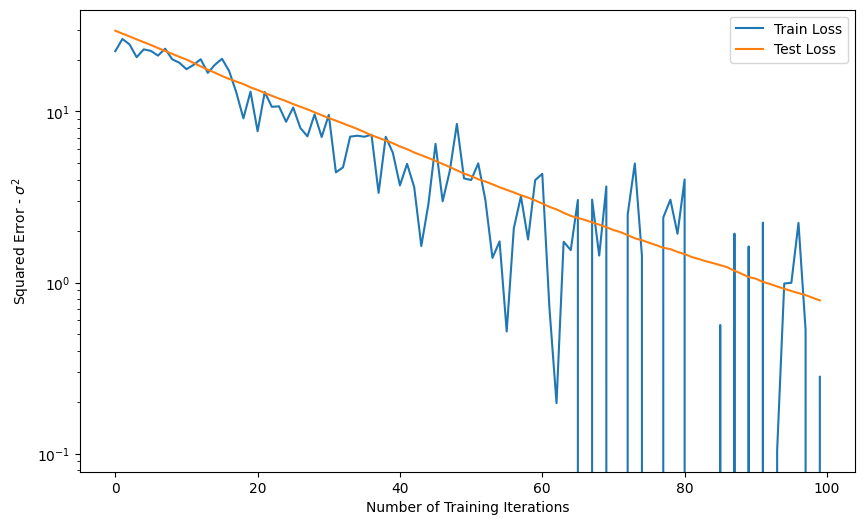

In [63]:
plt.figure(figsize=(10, 6))
train_sgd_mse_res = [mse - sigma**2 for mse in train_sgd_mse]
test_sgd_mse_res = [mse - sigma**2 for mse in test_sgd_mse]
plt.plot(train_sgd_mse_res, label='Train Loss')
plt.plot(test_sgd_mse_res, label='Test Loss')
plt.yscale('log')
plt.xlabel('Number of Training Iterations')
plt.ylabel(r'Squared Error - $\sigma^2$')
plt.legend()

## Q1: Scaling law for least-squares SGD.

Perform a sweep over learning rates. Consider the batch sizes between [2, 4, 16, 64, 256, 1024, 2048], and sweep over learning rates logarithmically with a resolution of $1.25$. For example, you should consider the learning rate of $0.001, 0.001 * 1.25, 0.001 * 1.25^2$, etc. **Make sure your learning rate sweep covers the optimal LR for each batch size (e.g. your optimal LR should not be at the boundary of your learning rate intervals.) You should be able to sweep around ~32 learning rates per batch size.

- Plot your learning rates on the same graph, with each batchsize as a different curve. You curve should resemble the example provided.
- Plot the relationship between batch size (x-axis) and the optimal learning rate (y-axis). What function does this resemble?

Hint: Many runs will result in very high losses if the iteration diverges. It will help to clip the losses to some ceiling value before plotting.

Hint 2: You may find that some batch sizes have a wide basin of optimal learning rates that perform roughly equivalently. In this case, it may help to plot the *average* learning rate that is within X% of the optimal. This can make the relationship more clear.

![fig-example](fig-example.png)

In [58]:
def collect_final_mse_dict(batch_sizes, lrs, train_fn, iters, avg_tail, **train_kwargs):
    """
    Sweep over all combinations of (batch_size, learning_rate) and compute the
    final test MSE for each setting.

    Parameters
    ----------
    batch_sizes : list of int
        Batch sizes to evaluate. For each batch size, the training function is
        run once per learning rate.

    lrs : list of float
        Learning rates to evaluate. The order is preserved in the output.

    train_fn : callable
        Training function with signature:
            train_fn(iters, batch_size, lr, **train_kwargs)
        returning:
            (train_mse_list, test_mse_list)

    iters : int
        Number of training iterations used for each run.

    avg_tail : int
        Number of final iterations over which to average the test MSE.
        If avg_tail <= 0, the full test MSE list is averaged.

    nan_fill : float or None
        If specified, replace NaN final MSE values with this number.

    **train_kwargs : dict
        Additional keyword arguments passed directly to `train_fn`.

    Returns
    -------
    final_mse_dict : dict
        Dictionary mapping each batch size to a list of final MSE values,
        one per learning rate in `lrs`. That is:
            final_mse_dict[bs][i] = final MSE using batch_sizes[bs], lrs[i].

    Notes
    -----
    This function standardizes experiment runs across different training
    functions (e.g., SGD linear model, MLP with SGD/Adam) and produces a
    consistent result dictionary for downstream plotting.
    """
    final_mse_dict = {}

    for bs in batch_sizes:
        final_mse_dict[bs] = []
        for lr in lrs:
            train_mse, test_mse = train_fn(iters=iters, batch_size=bs, lr=lr, **train_kwargs)
            test_mse = np.array(test_mse, dtype=float)
            tail = test_mse[-avg_tail:] if avg_tail > 0 else test_mse
            test_mse_mean = np.nanmean(tail)
            final_mse_dict[bs].append(test_mse_mean)

    return final_mse_dict

(<Figure size 1000x600 with 1 Axes>,
 <Axes: title={'center': 'Best Learning Rate vs Batch Size'}, xlabel='Batch Size', ylabel='Best Learning Rate'>)

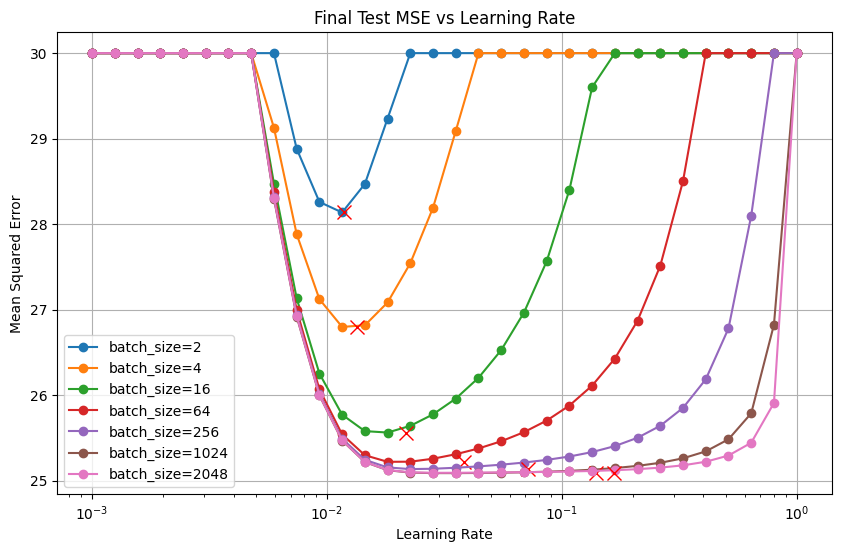

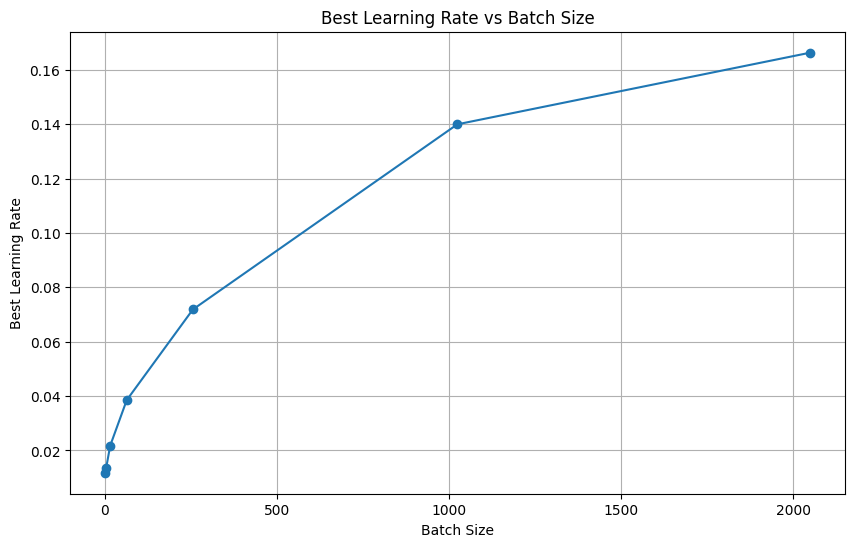

In [59]:
#### TODO:
lrs = np.logspace(-3, 0, 32)
batch_sizes = [2, 4, 16, 64, 256, 1024, 2048]

final_mse_dict = collect_final_mse_dict(batch_sizes, lrs, run_sgd, iters=100, avg_tail=10)
plot_lr_vs_mse(lrs, final_mse_dict, batch_sizes, nan_fill=30, clip_max=30, best_eps=0.5)
plot_best_lr_vs_batch(batch_sizes, final_mse_dict, lrs, best_eps=0.5)

## Q2: MLP with SGD

We will now repeat a similar study, using a two-layer MLP rather than a linear regression. Again, conduct a sweep on the relationship between batch size and optimal learning rate. How does this relationship compare to the optimum for least-squares SGD?

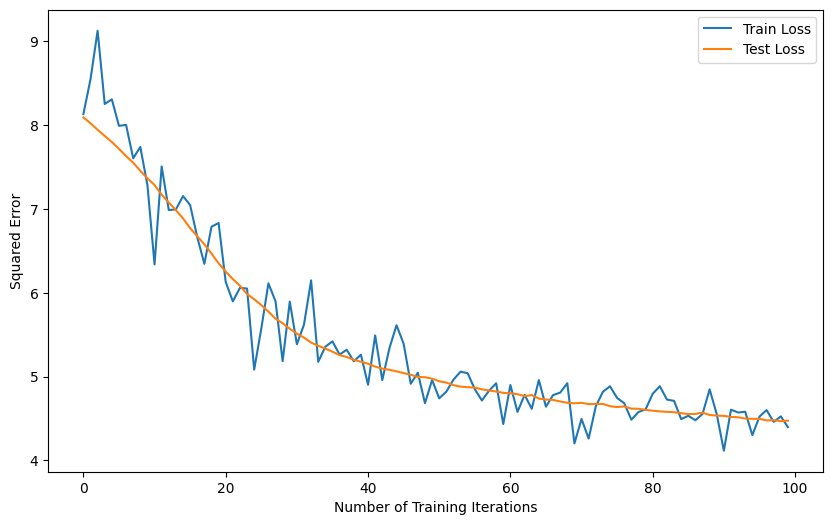

In [71]:
# Data Generation
N = 10_000
N_test = 1_000
D = 4
sigma = 2.0
seed = 0
X_train, y_train, X_test, y_test, w_true = generate_linear_regression_data(
    N=N,
    N_test=N_test,
    D=D,
    sigma=sigma,
    seed=seed,
)

X_test = torch.tensor(X_test, dtype=torch.float32)
y_test = torch.tensor(y_test, dtype=torch.float32)

def model_inst(D):
    model = torch.nn.Sequential(
        torch.nn.Linear(D, D),
        torch.nn.ReLU(),
        torch.nn.Linear(D, D)
    )

    loss_fn = torch.nn.MSELoss()
    return model, loss_fn

def train_mlp_sgd(iters, batch_size, lr, opt='SGD'):
    torch.manual_seed(0)
    np.random.seed(0)
    model, loss_fn = model_inst(D)
    if opt == 'SGD':
        optimizer = torch.optim.SGD(model.parameters(), lr=lr)
        scheduler = None
    elif opt == 'Adam':
        # TODO
        optimizer = torch.optim.Adam(model.parameters(), lr=lr, betas=(0.5, 0.5), weight_decay=0.01)
        scheduler1 = torch.optim.lr_scheduler.LinearLR(optimizer, start_factor=0.001, end_factor=1.0, total_iters=10)
        scheduler2 = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=iters-10)
        scheduler = torch.optim.lr_scheduler.SequentialLR(
            optimizer,
            schedulers=[scheduler1, scheduler2],
            milestones=[10],
        )
        # 
    else:
        raise ValueError("Optimizer not recognized")

    test_sgd_mse = []
    train_sgd_mse = []

    for i in range(iters):
        idx = np.random.randint(0, N, batch_size)
        x = torch.tensor(X_train[idx], dtype=torch.float32)
        y = torch.tensor(y_train[idx], dtype=torch.float32)
        
        y_pred = model(x)
        loss = loss_fn(y_pred, y)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        if scheduler is not None:
            scheduler.step()

        test_sgd_mse.append(loss_fn(model(X_test), y_test).item())
        train_sgd_mse.append(loss_fn(model(x), y).item())

    return train_sgd_mse, test_sgd_mse

mlp_train_mse, mlp_test_mse = train_mlp_sgd(iters=100, batch_size=256, lr=0.1)

plt.figure(figsize=(10, 6))
plt.plot(mlp_train_mse, label='Train Loss')
plt.plot(mlp_test_mse, label='Test Loss')
plt.xlabel('Number of Training Iterations')
plt.ylabel('Squared Error')
plt.legend()

Again, let's plot on log-linear scale minus the offset. Notice that the MLP converges to $\approx \sigma^2 + 0.57$ as opposed to $\sigma^2$.

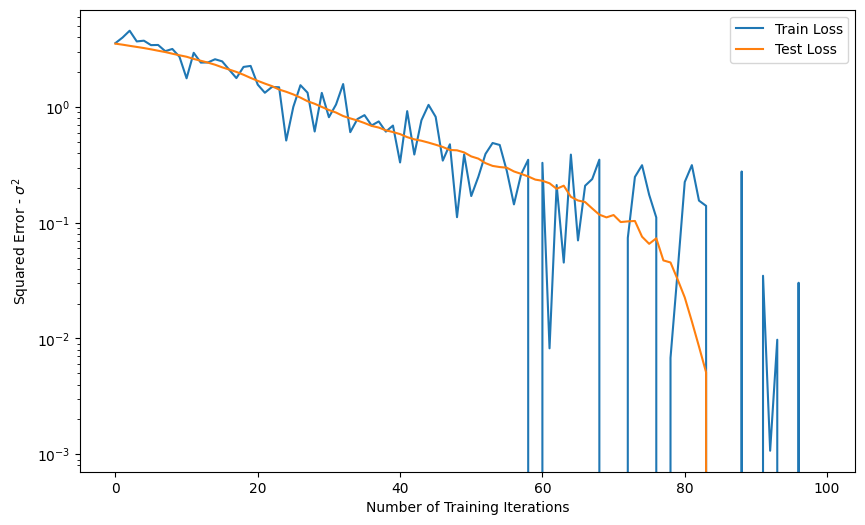

In [72]:
eps = 0.57
mlp_train_mse_res = [mse - (sigma**2 + eps) for mse in mlp_train_mse]
mlp_test_mse_res = [mse - (sigma**2 + eps) for mse in mlp_test_mse]

plt.figure(figsize=(10, 6))
plt.plot(mlp_train_mse_res, label='Train Loss')
plt.plot(mlp_test_mse_res, label='Test Loss')
plt.xlabel('Number of Training Iterations')
plt.ylabel(r'Squared Error - $\sigma^2$')
plt.yscale('log')
plt.legend()

/tmp/ipython-input-3725413846.py:55: RuntimeWarning: Mean of empty slice
  test_mse_mean = np.nanmean(tail)


(<Figure size 1000x600 with 1 Axes>,
 <Axes: title={'center': 'Best Learning Rate vs Batch Size for SGD'}, xlabel='Batch Size', ylabel='Best Learning Rate'>)

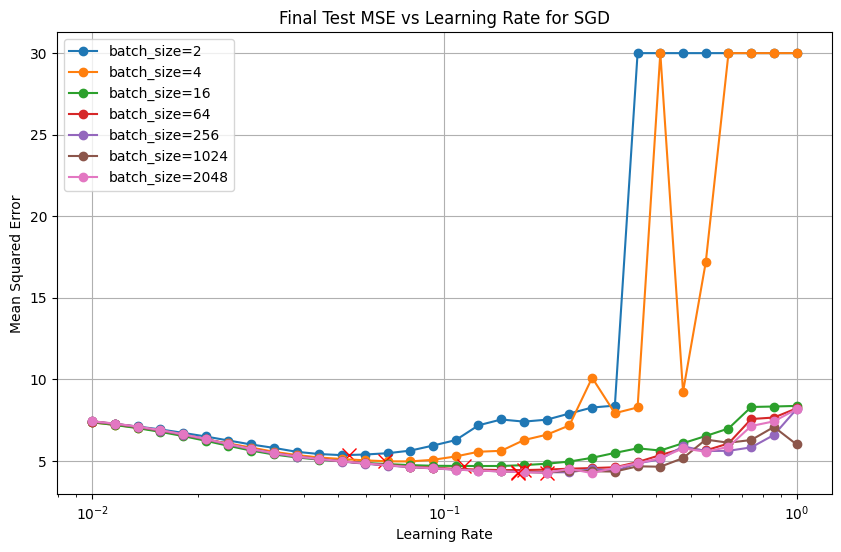

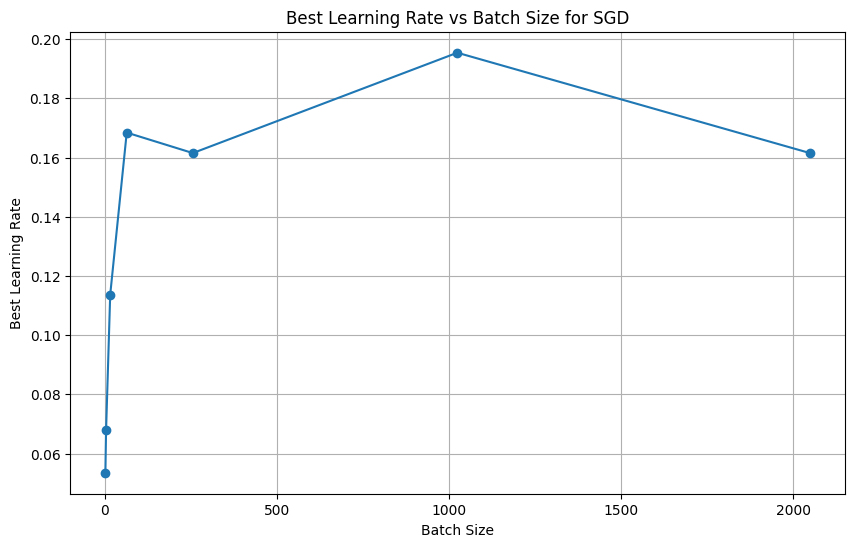

In [73]:
###### TODO
lrs = np.logspace(-2, 0, 32)
batch_sizes = [2, 4, 16, 64, 256, 1024, 2048]
final_mse_dict = collect_final_mse_dict(batch_sizes, lrs, train_mlp_sgd, iters=100, avg_tail=10, opt='SGD')
plot_lr_vs_mse(lrs, final_mse_dict, batch_sizes, nan_fill=30, clip_max=30, best_eps=0.5, title="Final Test MSE vs Learning Rate for SGD")
plot_best_lr_vs_batch(batch_sizes, final_mse_dict, lrs, best_eps=0.5, title="Best Learning Rate vs Batch Size for SGD")
###### 

#### Q3: MLP with Adam.

Finally, we will repeat the scaling law curve, but using the Adam optimizer. This time, implement a learning rate schedule, such that the learning rate has a linear warmup for 10 steps, then uses cosine decay for the rest of training. Use a beta1=0.5, beta2=0.5, and a weight decay of 0.001. As before, plot the comparison curves, then plot a curve of the batch size vs. optimal learning rate. Does the scaling for learning rate change with Adam vs. SGD?

(<Figure size 1000x600 with 1 Axes>,
 <Axes: title={'center': 'Best Learning Rate vs Batch Size for Adam'}, xlabel='Batch Size', ylabel='Best Learning Rate'>)

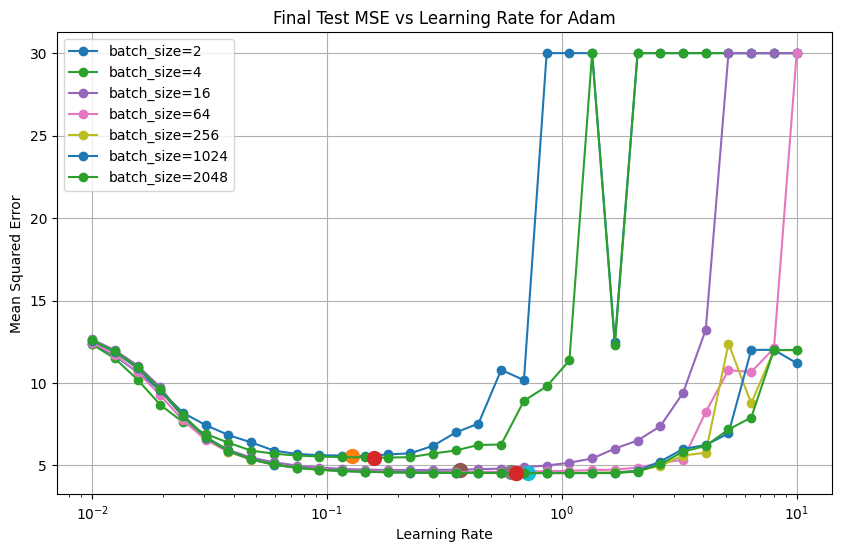

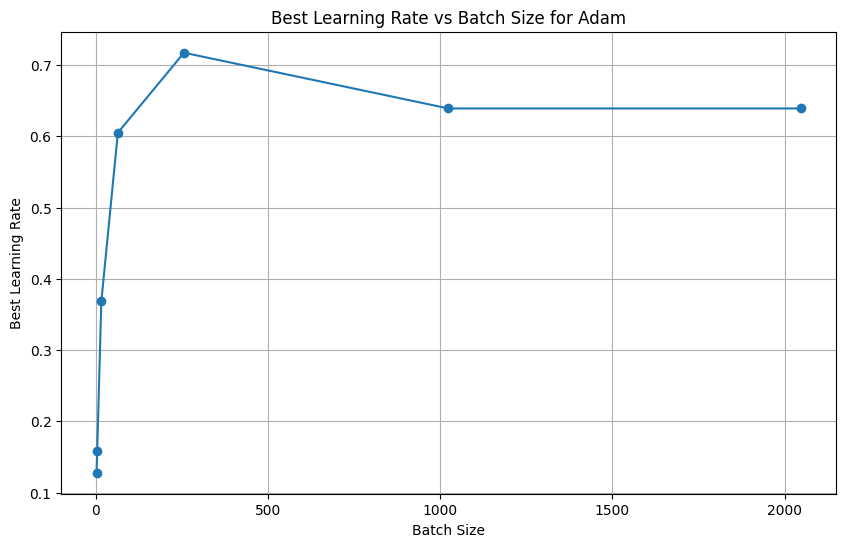

In [51]:
##### TODO

lrs = np.logspace(-2, 1, 32)

batch_sizes = [2, 4, 16, 64, 256, 1024, 2048]
collect_final_mse_dict(batch_sizes, lrs, train_mlp_sgd, iters=100, avg_tail=10, opt='Adam')
plot_lr_vs_mse(lrs, final_mse_dict, batch_sizes, nan_fill=30, clip_max=30, best_eps=0.5, title="Final Test MSE vs Learning Rate for Adam")
plot_best_lr_vs_batch(batch_sizes, final_mse_dict, lrs, best_eps=0.5, title="Best Learning Rate vs Batch Size for Adam")
######